# Mamba-MPC on the Van der Pol oscillator

Companion code for *Mamba Sequence Modeling Meets Model Predictive Control*
(Cevaal, de Jong, Lazar), IEEE Open Journal of Control Systems, 2026.

The Van der Pol oscillator is the paper's SISO study. This notebook covers the
whole pipeline end to end:

1. **Training data** &mdash; excite the plant with a filtered multisine and integrate it.
2. **Training** &mdash; fit the Mamba multi-step predictor.
3. **Validation** &mdash; open-loop prediction accuracy over the horizon.
4. **Reference tracking** &mdash; the closed loop behind the paper's comparison figure.
5. **Initial-condition sweep** &mdash; closed-loop behaviour from 100 random starts.
6. **Noise robustness** &mdash; the same loop with SNR20 measurement noise.
7. **Comparison** &mdash; Mamba-MPC against LSTM-MPC and Transformer-MPC.

Every model, the CasADi translation and the MPC problem itself live in the
`mambampc` package; this notebook only sets up experiments and plots results.

**Reproducing without retraining:** sections 1 and 2 take hours on a GPU. The
checkpoints used in the paper are in `checkpoints/`, so you can skip straight to
section 3 and everything downstream will run on CPU in minutes.

## Setup

In [1]:
import os
import sys
import pathlib

# Make the repository root importable without installing the package.
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

import casadi as cs
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.integrate import solve_ivp
from torch.utils.data import DataLoader, TensorDataset

from mambampc.data import (
    BestModelSaver,
    HankelMatricesStates,
    Sequence2SequenceStates,
)
from mambampc.models import MambaMPC
from mambampc.plotting import (
    comp_time_curve,
    fig_computation_time,
    fig_initial_conditions,
    fig_noise,
    fig_tracking,
)
from mambampc.mpc import setup_mpc
from mambampc.simulate import run_closed_loop, step_reference
from mambampc.systems import multisine, van_der_pol

# The CasADi model is built in float64; matching it here keeps the PyTorch and
# CasADi predictions identical (see tests/test_casadi_equivalence.py).
torch.set_default_dtype(torch.float64)

# Seeded so a fresh run is repeatable. The checkpoints shipped in checkpoints/
# were trained before seeding was added, so retraining gives a comparable but
# not bit-identical model -- see the README.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.8.0+cpu on cpu


## 1. Training data

A multisine excites every odd frequency up to 1000 with randomised phases, then
a low-pass filter shapes it so the oscillator is driven across its state space
rather than only at high frequency.

In [ ]:
T_period = 44000       # samples (40000 train + 4000 held out)
Ts = 0.1               # controller sampling time [s]
mu = 1.0               # Van der Pol damping parameter

# Multisine excitation, crest-factor optimised over 100 phase realisations.
u_data = 15 * multisine(
    N_points_per_period=T_period, N_periods=1,
    pmin=1, pmax=1000, n_crest_factor_optim=100, seed=SEED,
)

# Superimpose one slow sine so the signal also covers low frequencies.
u_data = np.array([u_data + np.sin(np.linspace(-np.pi, np.pi, T_period))]).T

# First-order low-pass, which keeps the excitation inside the plant's bandwidth.
u_filtered = np.zeros(len(u_data))
for i in range(len(u_data) - 1):
    u_filtered[i + 1] = 0.9 * u_filtered[i] + 0.1 * u_data[i]

plt.figure(figsize=(8, 3))
plt.plot(u_filtered, lw=0.8)
plt.title("Excitation signal")
plt.xlabel("sample")
plt.ylabel("$u$")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Integrate the oscillator one sampling period at a time under the excitation,
# carrying the final state forward as the next initial condition.
y0 = [2, 0]
x = [y0]
for i in range(len(u_data[:, 0])):
    u = u_data[i, 0]
    sol = solve_ivp(lambda t, y: van_der_pol(t, y, mu, u), [0, Ts], y0, method="RK45")
    y0 = sol.y[:, -1]
    x.append(y0)

x = np.array(x)
t_vec = np.arange(len(x)) * Ts

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].scatter(x[:, 0], x[:, 1], s=1)
ax[0].set_xlabel("$x_1$"); ax[0].set_ylabel("$x_2$")
ax[0].set_title("State-space coverage"); ax[0].grid(alpha=0.3)
ax[1].plot(t_vec, x[:, 0], lw=0.7, label="$x_1$")
ax[1].plot(t_vec, x[:, 1], lw=0.7, label="$x_2$")
ax[1].set_xlabel("t [s]"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_title("Trajectories")
plt.tight_layout(); plt.show()

In [ ]:
N = 10             # prediction horizon
BatchSize = 128
TestSetSize = 4000  # held out from the end of the record

u_train, x_train = u_data[:T_period - TestSetSize], x[:T_period - TestSetSize]
u_test, x_test = u_data[T_period - TestSetSize:], x[T_period - TestSetSize:]

# Saved channels-first, (n_channels, n_samples), matching the shipped arrays.
np.save("data/u_data_train.npy", u_train.T)
np.save("data/x_data_train.npy", x_train.T)
np.save("data/u_data_test.npy", u_test.T)
np.save("data/x_data_test.npy", x_test.T)

u_train, x_train = torch.DoubleTensor(u_train), torch.DoubleTensor(x_train)
u_test_t, x_test_t = torch.DoubleTensor(u_test), torch.DoubleTensor(x_test)

# Hankel matrices turn the record into (initial state, input sequence) ->
# (state sequence) triples: the seq2seq form the predictor is trained on.
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_train, x_train, N)
X, Y = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)

U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test_t, x_test_t, N)
X_test, Y_test = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)

if device == "cuda":
    X, Y, X_test, Y_test = X.cuda(), Y.cuda(), X_test.cuda(), Y_test.cuda()

train = DataLoader(TensorDataset(X, Y), batch_size=BatchSize, shuffle=False)
test = DataLoader(TensorDataset(X_test, Y_test), batch_size=BatchSize, shuffle=False)
print(f"train {tuple(X.shape)} -> {tuple(Y.shape)} | test {tuple(X_test.shape)}")

## 2. Training

Trains the predictor and keeps the best validation checkpoint. Hyperparameters
are encoded in the filename: `D<d_model>_dstate<d_state>_Conv<d_conv>_L<n_layers>`.

Skip this section to use the shipped checkpoints.

In [ ]:
filename = "D8_dstate8_Conv10_L2"
lr, wd, epochs, gamma = 1e-3, 1e-5, 2000, 0.998

X_sample, Y_sample = next(iter(train))
_, _, input_dim = X_sample.shape
_, _, output_dim = Y_sample.shape

model = MambaMPC(input_dim, output_dim, d_model=8, n_layers=2, d_conv=10, d_state=8)
if device == "cuda":
    model = model.cuda()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=gamma)
best_model_saver = BestModelSaver(filepath="checkpoints/" + filename)

train_loss, val_loss = [], []
for e in range(epochs):
    model.train()
    running = 0.0
    for X_b, Y_b in train:
        opt.zero_grad()
        # Loss is normalised by the target energy, so it reads as a relative error.
        loss = torch.mean((model(X_b).squeeze(0) - Y_b) ** 2) / torch.mean(Y_b ** 2)
        loss.backward()
        opt.step()
        running += loss.item()

    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for X_b, Y_b in test:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            vloss += (torch.mean((model(X_b) - Y_b) ** 2) / torch.mean(Y_b ** 2)).item()
    average_vloss = vloss / len(test)

    train_loss.append(running / len(train))
    val_loss.append(average_vloss)
    scheduler.step()

    if e % 10 == 0 and e != 0:
        print("Epoch %d | train %.5f | val %.5f" % (e, train_loss[-1], average_vloss))
        best_model_saver(current_valid_loss=average_vloss, model=model,
                         epoch=e, optimizer=opt, criterion=F.mse_loss)

## 3. Validation

Open-loop accuracy of the multi-step predictor on the held-out set. This is the
first section that runs from the shipped checkpoints alone.

In [12]:
# The paper's Van der Pol model. config_from_state_dict recovers the
# architecture from the checkpoint, so the hyperparameters need not be repeated.
CHECKPOINT = "D8_dstate8_Conv10_L6"

sd = torch.load("checkpoints/" + CHECKPOINT, map_location="cpu",
                weights_only=True)["model_state_dict"]
model = MambaMPC(**MambaMPC.config_from_state_dict(sd))
model.load_state_dict(sd)
model = model.double().eval()
print(MambaMPC.config_from_state_dict(sd))
print("parameters:", sum(p.numel() for p in model.parameters()))

{'in_dim': 3, 'out_dim': 2, 'd_model': 8, 'n_layers': 6, 'd_conv': 10, 'd_state': 8, 'expand_factor': 1, 'dt_rank': 4}
parameters: 3418


Hankel Matrices Generated
total absolute error    : 7.00933
root mean absolute error: 0.00239
R^2 x1: 1.00000
R^2 x2: 0.99999


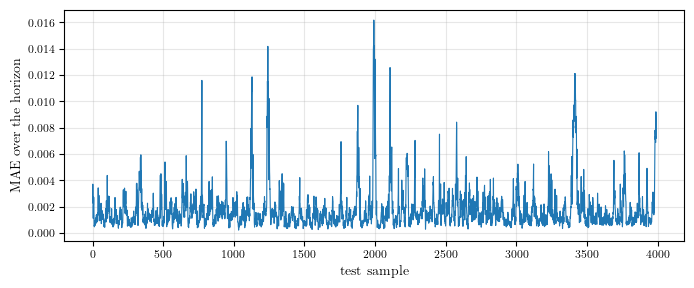

In [13]:
# Rebuild the test loader from the saved arrays so this section stands alone.
# The arrays are channels-first on disk; the Hankel builder wants time-first.
u_test_t = torch.DoubleTensor(np.load("data/u_data_test.npy")).transpose(0, 1)
x_test_t = torch.DoubleTensor(np.load("data/x_data_test.npy")).transpose(0, 1)
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test_t, x_test_t, N=10)
X_test, Y_test = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)
test = DataLoader(TensorDataset(X_test, Y_test), batch_size=128, shuffle=False)

with torch.no_grad():
    yhat = torch.cat([model(X_b) for X_b, _ in test]).numpy()

Y_np = Y_test.numpy()
MAE = np.mean(np.abs(yhat[:, :, 0] - Y_np[:, :, 0]), 1)
print("total absolute error    : %.5f" % np.sum(MAE))
print("root mean absolute error: %.5f" % np.sqrt(np.mean(MAE ** 2)))

from sklearn.metrics import r2_score
for i, name in enumerate(("x1", "x2")):
    print("R^2 %s: %.5f" % (name, r2_score(Y_np[:, :, i].ravel(), yhat[:, :, i].ravel())))

plt.figure(figsize=(8, 3))
plt.plot(MAE, lw=0.8)
plt.xlabel("test sample"); plt.ylabel("MAE over the horizon")
plt.grid(alpha=0.3); plt.show()

## 4. Reference tracking

The closed loop behind the paper's comparison figure. The input is bounded to
$|u| \le 20$; without that bound the nonlinear program can pick an unbounded
input at a reference step and the loop diverges.

In [10]:
Ts, N, L = 0.1, 10, 400
Q, R, Rd, S = 100, 0, 0.5, 0       # tracking, input, input-rate, terminal
U_MAX = 20.0

ref = step_reference([0.8, 2.5, -1.5, 1.2], 100)


def vdp_plant(state, u):
    """Euler-discretised Van der Pol, the true plant in the closed loop."""
    x1, x2 = state
    u1 = float(np.atleast_1d(u)[0])
    return np.array([x1 + Ts * x2, x2 + Ts * ((1 - x1 ** 2) * x2 - x1 + u1)])


solver, opt_x_num, opt_p_num, lbx, ubx = setup_mpc(
    model, N=N, n_u=1, n_x=1, Q=Q, R=R, Rd=Rd, S=S,
    n_state_params=2, terminal="replace", u_bounds=(-U_MAX, U_MAX),
)

out = run_closed_loop(
    solver, opt_x_num, opt_p_num, vdp_plant,
    x0=[0.0, 0.0], ref=ref, N=N, steps=L - N,
    n_u=1, n_x=1, lbx=lbx, ubx=ubx, progress=True,
)

np.save("results/mamba/xvec1_reference_tracking_%s.npy" % CHECKPOINT, out["states"][1:, 0])
np.save("results/mamba/xvec2_reference_tracking_%s.npy" % CHECKPOINT, out["states"][1:, 1])
np.save("results/mamba/uvec_reference_tracking_%s.npy" % CHECKPOINT, out["inputs"])
print("median solve time: %.1f ms" % (1e3 * np.median(out["solve_time"])))

closed loop: 100.0%
median solve time: 29.2 ms


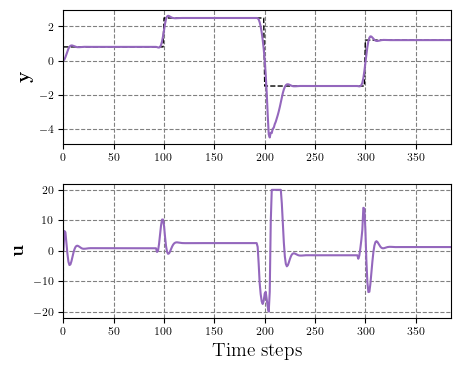

In [11]:
# Paper Fig. 8, single-controller version: output over input, the paper's style.
fig_tracking(
    ref[:L - N],
    {"Mamba-MPC": (out["states"][1:, 0], out["inputs"])},
    save_to="figures/VDP_MambaMPC_reference_tracking",
)
plt.show()

## 5. Initial-condition sweep

The same controller started from 100 random initial conditions, showing the
closed loop converges from across the state space.

In [25]:
N_IC = 100
rng = np.random.default_rng(SEED)
x0_samples = rng.uniform(-3, 3, size=(N_IC, 2))

ref_zero = np.zeros(400)
solver_ic, opt_x_ic, opt_p_ic, lbx_ic, ubx_ic = setup_mpc(
    model, N=N, n_u=1, n_x=1, Q=Q, R=R, Rd=Rd, S=S,
    n_state_params=2, terminal="replace", u_bounds=(-U_MAX, U_MAX),
)

ic_states, ic_inputs = [], []
for i, x0 in enumerate(x0_samples):
    res = run_closed_loop(
        solver_ic, opt_x_ic, opt_p_ic, vdp_plant,
        x0=x0, ref=ref_zero, N=N, steps=len(ref_zero) - N,
        n_u=1, n_x=1, lbx=lbx_ic, ubx=ubx_ic,
    )
    ic_states.append(res["states"])
    ic_inputs.append(res["inputs"])
    print("\rinitial condition %d/%d" % (i + 1, N_IC), end="", flush=True)
print()

ic_states = np.array(ic_states)
ic_inputs = np.array(ic_inputs)
np.save("results/mamba/initial_conditions_states_%s.npy" % CHECKPOINT, ic_states)
np.save("results/mamba/initial_conditions_inputs_%s.npy" % CHECKPOINT, ic_inputs)

initial condition 100/100


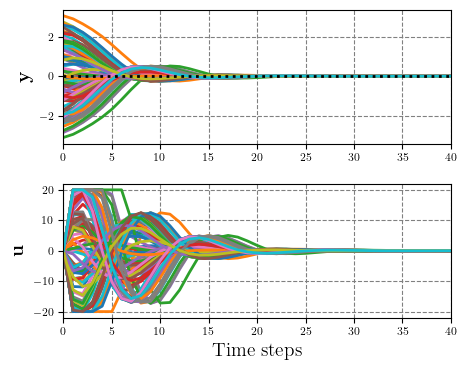

In [26]:
# Paper Fig. 7: every trajectory takes the next colour of the default cycle,
# and the origin reference is laid on top.
fig_initial_conditions(
    ic_states[:, 1:, 0], ic_inputs,
    save_to="figures/VDP_MambaMPC_initial_conditions",
)
plt.show()

## 6. Noise robustness

The measurement handed to the controller is corrupted with SNR20 Gaussian noise
while the plant itself is stepped from the clean state &mdash; sensor noise, not
process noise. The predictor used here was trained on noisy data
(`D8_dstate8_Conv10_L6_SNR20`).

The noise is seeded, so this section is repeatable. The published run predates
the seeding, so the trajectories match statistically rather than exactly.

In [ ]:
NOISE_CHECKPOINT = "D8_dstate8_Conv10_L6_SNR20"
NOISE_STD = [0.16221216, 0.13606953]   # SNR 20 dB on x1 and x2
N_REALISATIONS = 100

sd_noise = torch.load("checkpoints/" + NOISE_CHECKPOINT, map_location="cpu",
                      weights_only=True)["model_state_dict"]
model_noise = MambaMPC(**MambaMPC.config_from_state_dict(sd_noise))
model_noise.load_state_dict(sd_noise)
model_noise = model_noise.double().eval()

ref_noise = step_reference([0.8, 1.5, -0.8, -1.5], 100)

solver_n, opt_x_n, opt_p_n, lbx_n, ubx_n = setup_mpc(
    model_noise, N=N, n_u=1, n_x=1, Q=Q, R=R, Rd=Rd, S=S,
    n_state_params=2, terminal="replace", u_bounds=(-U_MAX, U_MAX),
)

rng = np.random.default_rng(SEED)
noise_states, noise_inputs = [], []
for i in range(N_REALISATIONS):
    noise = rng.normal(loc=[0, 0], scale=NOISE_STD, size=(len(ref_noise), 2))
    res = run_closed_loop(
        solver_n, opt_x_n, opt_p_n, vdp_plant,
        x0=[0.0, 0.0], ref=ref_noise, N=N, steps=len(ref_noise) - N,
        n_u=1, n_x=1, noise=noise, lbx=lbx_n, ubx=ubx_n,
    )
    noise_states.append(res["states"])
    noise_inputs.append(res["inputs"])
    print("\rrealisation %d/%d" % (i + 1, N_REALISATIONS), end="", flush=True)
print()

noise_states = np.array(noise_states)
noise_inputs = np.array(noise_inputs)
np.save("results/mamba/Mamba_VDP_N10_NoiseSNR20_x1.npy", noise_states[:, 1:, 0])
np.save("results/mamba/Mamba_VDP_N10_NoiseSNR20_x2.npy", noise_states[:, 1:, 1])
np.save("results/mamba/Mamba_VDP_N10_NoiseSNR20_uvec.npy", noise_inputs)

realisation 10/10


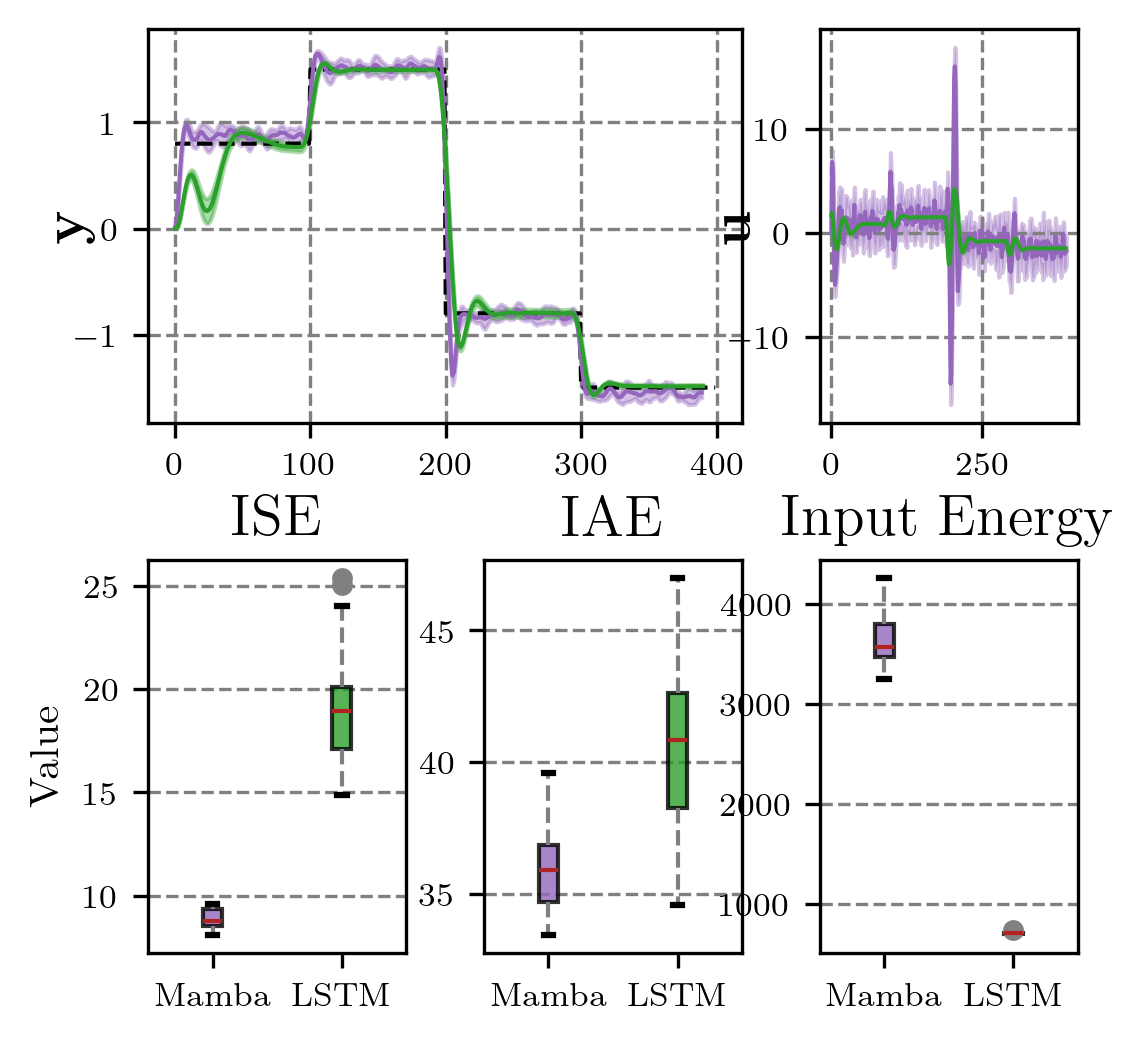

In [29]:
# Paper Fig. 11: mean +/- one standard deviation across the realisations, over
# boxplots of the per-realisation tracking and input-energy metrics.
runs_noise = {"Mamba-MPC": (noise_states[:, 1:, 0], noise_inputs)}

lstm_noise_y = "results/lstm/LSTM_VDP_NoiseSNR20_xvec1.npy"
if os.path.exists(lstm_noise_y):
    runs_noise["LSTM-MPC"] = (
        np.load(lstm_noise_y),
        np.load("results/lstm/LSTM_VDP_NoiseSNR20_uvec.npy"),
    )
else:
    print("missing (skipped):", lstm_noise_y)

fig_noise(
    ref_noise, runs_noise,
    save_to="figures/VDP_MambaMPC_vs_LSTM-MPC_noise_SNR20",
)
plt.show()

## 7. Comparison with LSTM-MPC and Transformer-MPC

The paper's three-way comparison. The LSTM and Transformer trajectories are the
stored results of their own closed-loop runs, in `results/lstm/` and
`results/transformer/` &mdash; see the README for what is re-runnable and what is not.

Transformer-MPC  MAE 0.24553   MSE 0.21428
LSTM-MPC         MAE 0.18207   MSE 0.11708
Mamba-MPC        MAE 0.06004   MSE 0.04379


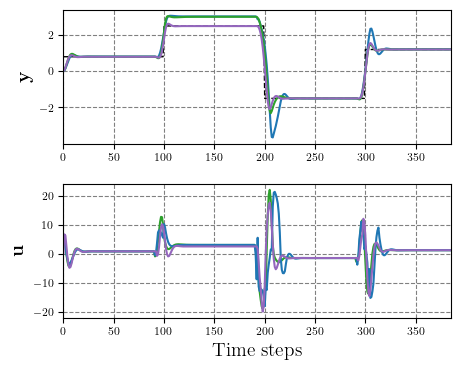

In [30]:
def load_trace(path, length):
    """Load a stored trajectory and align it to `length` samples.

    The LSTM runs stored one extra leading sample; trimming it lines all three
    methods up on the same time base.
    """
    a = np.load(path).squeeze()
    return a[len(a) - length:] if len(a) > length else a


mamba_y = out["states"][1:, 0]
n = len(mamba_y)

# Insertion order is draw order, so Mamba goes in last and lands on top.
runs = {}
for label, y_path, u_path in (
    ("Transformer-MPC",
     "results/transformer/xvec1_reference_tracking.npy",
     "results/transformer/uvec_reference_tracking.npy"),
    ("LSTM-MPC",
     "results/lstm/LSTM_VDP_ReferenceTracking_xvec1.npy",
     "results/lstm/LSTM_VDP_ReferenceTracking_uvec.npy"),
):
    if os.path.exists(y_path):
        runs[label] = (load_trace(y_path, n), load_trace(u_path, n))
    else:
        print("missing (skipped):", y_path)
runs["Mamba-MPC"] = (mamba_y, out["inputs"])

for label, (traj, _) in runs.items():
    err = traj - ref[:len(traj)]
    print("%-16s MAE %.5f   MSE %.5f" % (label, np.mean(np.abs(err)), np.mean(err ** 2)))

# Paper Fig. 8. The input panel is drawn in a different order so that no curve
# is completely hidden, exactly as in the paper.
fig_tracking(
    ref[:n], runs,
    input_order=[k for k in ("LSTM-MPC", "Transformer-MPC", "Mamba-MPC") if k in runs],
    save_to="figures/VDP_reference_tracking_comparison",
)
plt.show()

## 8. Computation time versus prediction horizon

Mamba-MPC        N=5:0.007s  N=10:0.038s  N=15:0.125s  N=20:0.282s  N=25:0.445s  N=30:0.724s  N=35:0.981s  N=40:1.568s  N=45:1.773s  N=50:2.369s
Transformer-MPC  N=5:0.035s  N=10:0.088s  N=15:0.238s  N=20:0.638s  N=25:0.968s  N=30:2.219s  N=35:2.809s  N=40:4.855s  N=45:7.570s  N=50:13.390s
LSTM-MPC         N=5:0.057s  N=10:0.200s  N=15:0.310s  N=20:0.527s  N=25:0.730s  N=30:1.071s  N=35:1.604s  N=40:1.871s  N=45:2.297s  N=50:2.388s


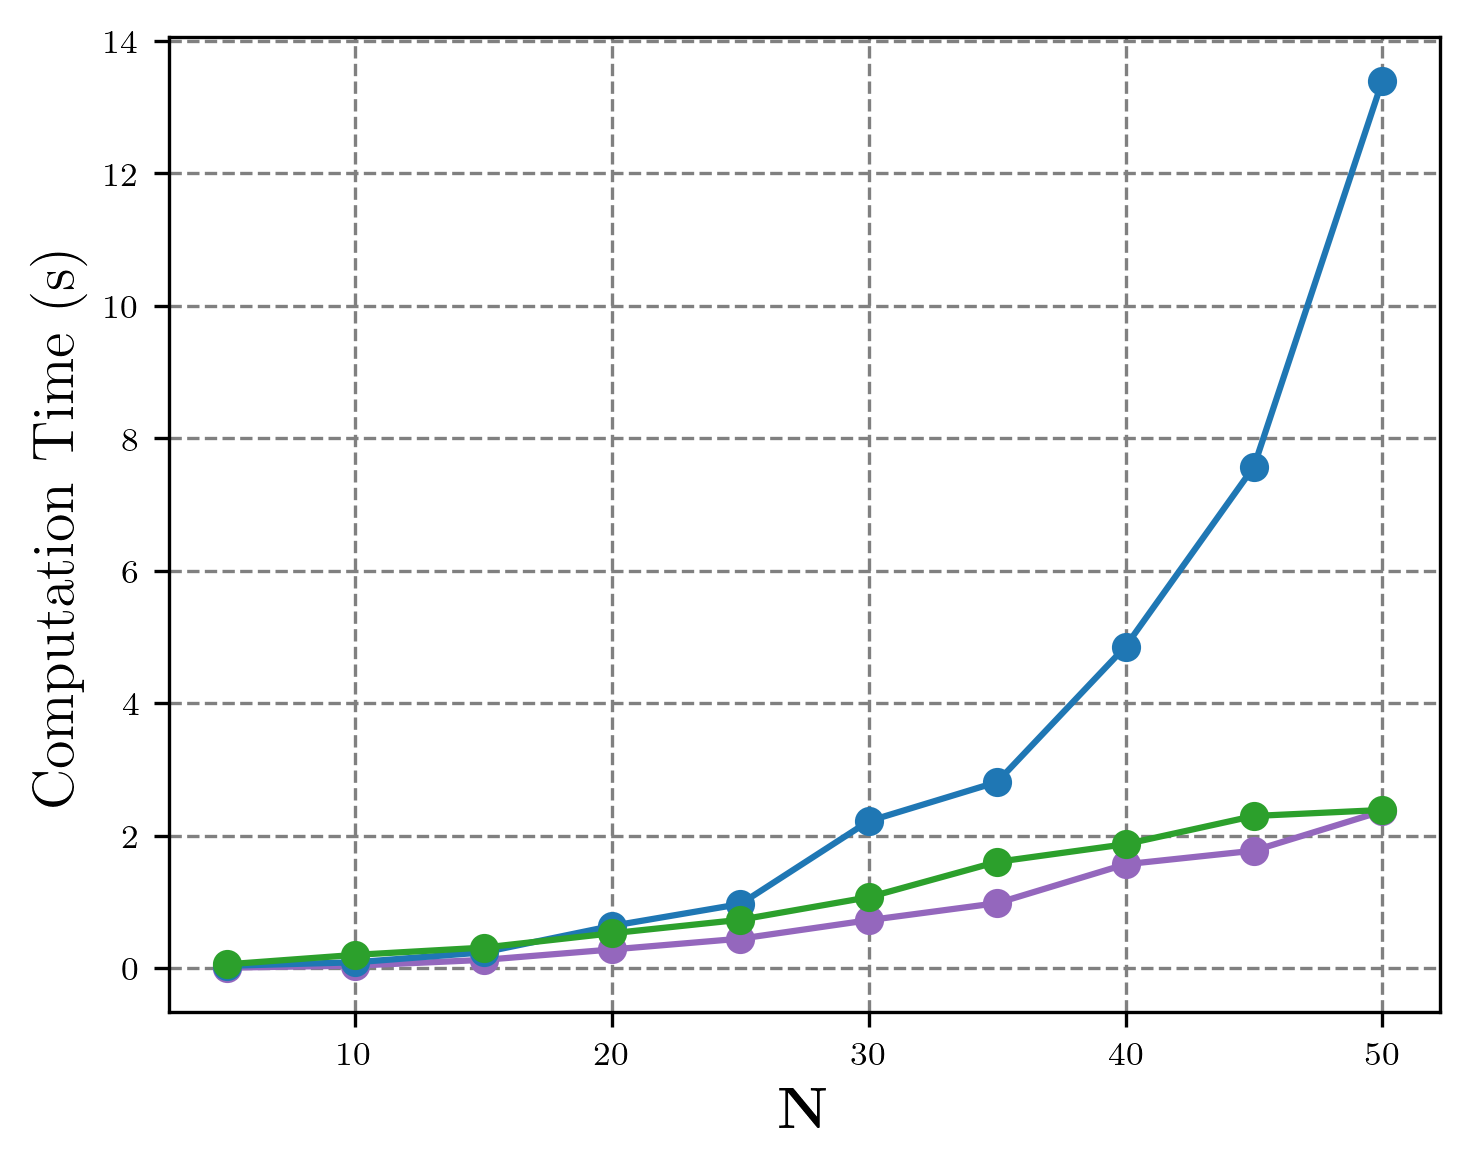

In [31]:
# Paper Fig. 9. These are the timings recorded for the paper, replotted -- a
# fresh run would time this machine instead. Each record is an object array of
# (horizon, solve times) rows, hence allow_pickle; `comp_time_curve` averages
# the repeated runs per horizon.
series = {}
for label, sub in (("Mamba-MPC", "mamba"),
                   ("Transformer-MPC", "transformer"),
                   ("LSTM-MPC", "lstm")):
    path = "results/%s/comp_time_vs_N.npy" % sub
    if os.path.exists(path):
        series[label] = comp_time_curve(np.load(path, allow_pickle=True))
    else:
        print("missing (skipped):", path)

for label, (horizons, times) in series.items():
    print("%-16s %s" % (label, "  ".join("N=%d:%.3fs" % (n, t)
                                         for n, t in zip(horizons, times))))

fig_computation_time(series, save_to="figures/VDP_computation_time_vs_N")
plt.show()